In [7]:
import zipfile
import os

# Path to your ZIP file
zip_path = r'C:/Users/HP/Downloads/balanced_labeled_photos.zip'
extract_path = r'yelp_photos'  # where to extract

# Unzip
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# Check folders
print("Extracted folders:", os.listdir(extract_path))


Extracted folders: ['balanced_labeled_photos', 'Dataset_User_Agreement.pdf', 'photos', 'photos.json']


In [8]:
import os

data_root = "yelp_photos"

print("Contents of data root:", os.listdir(data_root))
print("Contents of balanced_labeled_photos:", os.listdir(os.path.join(data_root, "balanced_labeled_photos")))
print("Contents of photos:", os.listdir(os.path.join(data_root, "photos")))


Contents of data root: ['balanced_labeled_photos', 'Dataset_User_Agreement.pdf', 'photos', 'photos.json']
Contents of balanced_labeled_photos: ['drink', 'food', 'inside', 'menu', 'outside']


IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [5]:
import os

data_root = "yelp_photos"
folder = "balanced_labeled_photos"
full_path = os.path.join(data_root, folder)

# List only first 10 files from each class folder
for class_folder in os.listdir(full_path):
    class_path = os.path.join(full_path, class_folder)
    files = os.listdir(class_path)
    print(f"Class '{class_folder}' has {len(files)} images. Here are 10 samples:")
    print(files[:10])


Class 'drink' has 15670 images. Here are 10 samples:
['--puCF1Lauwb3k6vrVVvfQ.jpg', '--y-d0b4_JQeKv7Yz39_Kw.jpg', '-0-Sor-tVeKH_KXSWI8SMw.jpg', '-03jEudW-0CXZhRhY9j3cg.jpg', '-07rvFvU6UOTuSEGa6HR9A.jpg', '-1h8RaVNoRDMJ1TuR--UPw.jpg', '-1wBDCpkQRt0X4QqhO5uMw.jpg', '-26yvqotk0rqT6OFGXTaOw.jpg', '-3-BFGlvZS2GA1yxdqm3Mw.jpg', '-32lR19VYAZQok6Z8tN_9w.jpg']
Class 'food' has 20000 images. Here are 10 samples:
['--3JQ4MlO-jHT9xbo7liug.jpg', '--9cH8_rrskfmYvONaJpgQ.jpg', '--j4xVIdIlYpOmZbs7iszg.jpg', '--wxyCFpNg13pVl00xvlXg.jpg', '--zScnI03KioBVMtcOK6oQ.jpg', '-0A6_xM5K-YK8wwnGgBpEQ.jpg', '-0fa0mOVKrJW90MFFxVImg.jpg', '-0l6FrIjTVo8x92V0XBTZA.jpg', '-0SNYNp7RKMuGqSc_Rycqg.jpg', '-10Ge63S6TdapDZV5ZGJLw.jpg']
Class 'inside' has 20000 images. Here are 10 samples:
['--4DfhW2sJvjeC90KEDX3g.jpg', '--7SiWWk_OHbdmcU4pNDQw.jpg', '--AU_cPMgrWSPluP1v8n_Q.jpg', '--dacvi4Y_8ACp-10nafMA.jpg', '--e8vgtonVwPXG3n6lfBLA.jpg', '--gjH9oA92f7OuTSovXjCg.jpg', '--kP__1IcWsQE0ycWKT0bg.jpg', '--WioehVQHeKzop8t3_8Bw.jpg'

In [9]:
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# Path to your image folder with subfolders (classes)
data_dir = "yelp_photos/balanced_labeled_photos"

# Parameters
img_size = (128, 128)
batch_size = 32


In [10]:
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_gen = datagen.flow_from_directory(
    data_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_gen = datagen.flow_from_directory(
    data_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)


Found 75392 images belonging to 5 classes.
Found 18847 images belonging to 5 classes.


In [13]:
model = models.Sequential([
    layers.Input(shape=(img_size[0], img_size[1], 3)),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(train_gen.num_classes, activation='softmax')  # number of classes dynamically from train_gen
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)                    │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 28, 28, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │       3,211,392 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 5)                   │             645 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,305,285 (12.61 MB)

 Trainable params: 3,305,285 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
history = model.fit(
    train_gen,
    epochs=5,
    validation_data=val_gen
)


C:\Users\HP\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
2356/2356 ━━━━━━━━━━━━━━━━━━━━ 1602s 677ms/step - accuracy: 0.6899 - loss: 0.7997 - val_accuracy: 0.8687 - val_loss: 0.3629
Epoch 2/5
2356/2356 ━━━━━━━━━━━━━━━━━━━━ 547s 232ms/step - accuracy: 0.8651 - loss: 0.3920 - val_accuracy: 0.8987 - val_loss: 0.2904
Epoch 3/5
2356/2356 ━━━━━━━━━━━━━━━━━━━━ 520s 221ms/step - accuracy: 0.8953 - loss: 0.3024 - val_accuracy: 0.9007 - val_loss: 0.2808
Epoch 4/5
2356/2356 ━━━━━━━━━━━━━━━━━━━━ 510s 216ms/step - accuracy: 0.9133 - loss: 0.2507 - val_accuracy: 0.9154 - val_loss: 0.2639
Epoch 5/5
2356/2356 ━━━━━━━━━━━━━━━━━━━━ 506s 215ms/step - accuracy: 0.9261 - loss: 0.2072 - val_accuracy: 0.9170 - val_loss: 0.2518


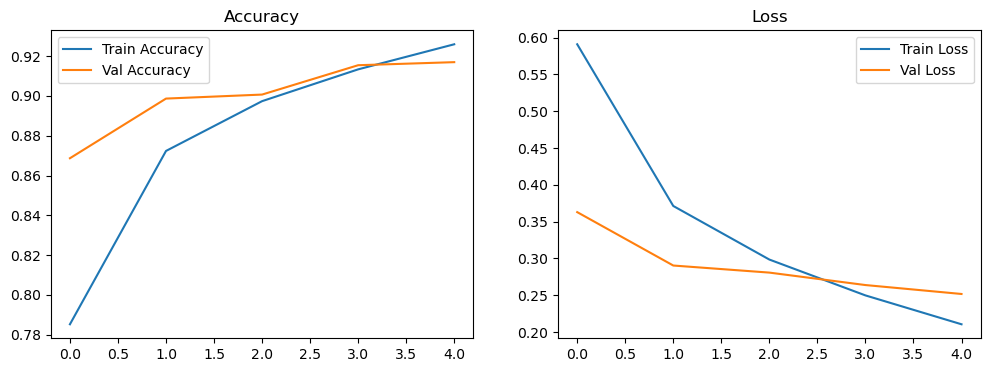

In [15]:
plt.figure(figsize=(12,4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss')

plt.show()


In [1]:
pip install keras-tuner


   ---------------------------------------- 0.0/129.1 kB ? eta -:--:--
   --------- ----------------------------- 30.7/129.1 kB 660.6 kB/s eta 0:00:01
   -------------------------------------- - 122.9/129.1 kB 1.4 MB/s eta 0:00:01
   ---------------------------------------- 129.1/129.1 kB 1.3 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [16]:
import keras_tuner as kt
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping

def build_model(hp):
    model = models.Sequential()
    model.add(layers.Input(shape=(img_size[0], img_size[1], 3)))

    # Convolutional Block 1
    model.add(layers.Conv2D(
        filters=hp.Int('conv1_filters', 32, 64, step=16),
        kernel_size=3,
        activation='relu',
        kernel_regularizer=regularizers.l2(hp.Float('l2', 1e-4, 1e-2, sampling='log'))
    ))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D(2, 2))

    # Convolutional Block 2
    model.add(layers.Conv2D(
        filters=hp.Int('conv2_filters', 64, 128, step=32),
        kernel_size=3,
        activation='relu'
    ))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D(2, 2))

    # Convolutional Block 3
    model.add(layers.Conv2D(
        filters=hp.Int('conv3_filters', 128, 256, step=64),
        kernel_size=3,
        activation='relu'
    ))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D(2, 2))

    model.add(layers.GlobalAveragePooling2D())

    model.add(layers.Dense(
        units=hp.Int('dense_units', 64, 256, step=64),
        activation='relu'
    ))
    model.add(layers.Dropout(hp.Float('dropout', 0.3, 0.7, step=0.1)))

    model.add(layers.Dense(train_gen.num_classes, activation='softmax'))

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# Initialize tuner
tuner = kt.Hyperband(
    build_model,
    objective='val_accuracy',
    max_epochs=20,
    factor=3,
    directory='cnn_tuning',
    project_name='fire_detection'
)

# Early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Search for best hyperparameters
tuner.search(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    callbacks=[early_stop]
)


Trial 1 Complete [00h 46m 40s]
val_accuracy: 0.8212447762489319

Best val_accuracy So Far: 0.8212447762489319
Total elapsed time: 00h 46m 40s

Search: Running Trial #2

Value             |Best Value So Far |Hyperparameter
48                |48                |conv1_filters
0.0012287         |0.0061671         |l2
128               |64                |conv2_filters
128               |128               |conv3_filters
192               |192               |dense_units
0.4               |0.6               |dropout
3                 |3                 |tuner/epochs
0                 |0                 |tuner/initial_epoch
2                 |2                 |tuner/bracket
0                 |0                 |tuner/round

Epoch 1/3
 873/2356 ━━━━━━━━━━━━━━━━━━━━ 14:21 581ms/step - accuracy: 0.6274 - loss: 0.9840

KeyboardInterrupt: 

In [17]:
from sklearn.metrics import roc_auc_score
from tensorflow.keras.utils import to_categorical

# Get true labels and predicted probabilities
val_gen.reset()
y_pred_probs = model.predict(val_gen, verbose=1)
y_true = val_gen.classes
y_true_onehot = to_categorical(y_true, num_classes=train_gen.num_classes)

# Calculate macro average AUC
auc_score = roc_auc_score(y_true_onehot, y_pred_probs, multi_class='ovr', average='macro')

print(f"Multiclass AUC (macro average): {auc_score:.4f}")


589/589 ━━━━━━━━━━━━━━━━━━━━ 54s 92ms/step
Multiclass AUC (macro average): 0.9918


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Get predictions and true labels
val_gen.reset()
y_pred_probs = model.predict(val_gen, verbose=1)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true = val_gen.classes

# Get class labels
class_labels = list(val_gen.class_indices.keys())

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Display confusion matrix as heatmap
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
plt.figure(figsize=(8, 6))
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title('Confusion Matrix')
plt.show()


345/589 ━━━━━━━━━━━━━━━━━━━━ 23s 97ms/step